# Miniproyecto 3: ¿Te gustaría ser *Data Scientist Senior*?
#### **Curso:** Introducción a Minería de Datos y Machine Learning

---

**¡Tienes una oferta de trabajo!**

Una empresa se enteró de tu **excelente** trabajo como *Data Scientist Junior* en **AMAZOFF**.

¡Quieren que trabajes con ellos como ***Data Scientist Senior***!

Para la entrevista de trabajo, te han pedido que utilices tus poderes de ***Machine Learning*** en sus bases de datos.

**¿Estás listo para el reto?**

# ¿Qué empresa te quiere en su equipo?

En este MP3 deberás buscar una base de datos y aplicar tus conocimientos de *Machine Learning*.

Una vez elegida la base de datos, deberás inventar una empresa ficticia que te busca para el puesto de *Data Scientist Senior*.

La empresa debe de tener sentido con los datos y lo que quieres predecir usando *Machine Learning*.

## ¿Cómo elegir la base de datos?

Puedes utilizar cualquier base de datos que esté publicada en internet de forma libre. Esta base de datos debe por lo menos cumplir con:

- Tener al menos 1000 filas después de limpiarla.
- Tener al menos 5 columnas con información relevante (no cuentan: *ids*, *index*, etc.) después de limpiarla.
- No tener consideraciones éticas graves. Ejemplo: datos privados de una empresa real.
- Debe tener al menos una columna (aparte de las 5 relevantes) para predecir (columna `label`o `target`).
- El ejercio contempla solo una base de datos. Si tus datos vienen originalmente en más de una, deberás juntarlos (ejemplo: `join`, `merge`, etc.) en la pregunta 1. Debes cargar todos los datos necesarios en la sección de **Preámbulo**.

# Define tu empresa

> **¡No olvides elegir tus datos primero!**

- **Nombre de la empresa**: **BIODATASCIENCE RESEARCHES**
- **Descripción de la empresa**: Empresa internacional dedicada al análisis de datos biológicos.

# Pauta de Evaluación

Este MP3 está enfocado en responder preguntas de negocio relevantes para tu nueva empresa (creada por ti).

### Preguntas de Negocio

1. (10 puntos) ¿Cargaste los datos? ¡Toca limpiarlos! La empresa no ha tocado esos datos. ¿Se los puedes explicar?
2. (15 puntos) Datos limpios. Pues, es hora de un... ¡Análisis Exploratorio de Datos!
3. (10 puntos) ¡Vamos con el ML... ¿Qué? ¿Hay que preparar los datos primero?
4. (20 puntos) ¡Grupos everywhere!
5. (25 puntos) ¿Podemos predecir algo con estos datos? Demostremos nuestra experiencia.
6. (20 puntos) ¿Puedes explicar mejor tus resultados? ¡De Junior a Senior!

### Tener en consideración:

En caso de que el código esté bien, pero no se responda (usando celdas de texto) la pregunta de negocio (sección **Explicación**), **se asignará máximo la mitad de puntos** de esa pregunta.

> # ¡NO OLVIDES GUARDAR Y SUBIR EL NOTEBOOK A LA PLATAFORMA CUANDO TERMINES! FORMATO .ipynb

> # ¡NO OLVIDES SUBIR LOS DATOS ORIGINALES A LA PLATAFORMA!

# Preámbulo

In [2]:
# Agrega todas las librerias necesarias para el proyecto en su sección correspondiente

# Clustering
from sklearn.cluster import KMeans

# Machine Learning
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

# General Data Science
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

In [4]:
# Esta configuración permite que los dataframes se muestren completos.
pd.set_option('display.max_columns', None)

In [5]:
# PARÁMETROS (puedes modificar esta sección)

DATA_PATH = './' # Si tienes el archivo en otro lugar, cámbialo.
RANDOM_STATE = 0 # ¡Cámbialo a tu número favorito!

In [6]:
# Esta celda se encarga de cargar los datos. ¿La necesitas modificar? ¡Adelante!

df = pd.read_csv(DATA_PATH + 'usa_county_wise.csv')
print(f'{df.shape[0]} rows x {df.shape[1]} columns')
df.head(5)

627920 rows x 14 columns


,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat,Long_,Combined_Key,Date,Confirmed,Deaths
0,16,AS,ASM,16,60.0,NaN,American Samoa,US,-14.271000,-170.132000,"American Samoa, US",1/22/20,0,0
1,316,GU,GUM,316,66.0,NaN,Guam,US,13.444300,144.793700,"Guam, US",1/22/20,0,0
2,580,MP,MNP,580,69.0,NaN,Northern Mariana Islands,US,15.097900,145.673900,"Northern Mariana Islands, US",1/22/20,0,0
3,63072001,PR,PRI,630,72001.0,Adjuntas,Puerto Rico,US,18.180117,-66.754367,"Adjuntas, Puerto Rico, US",1/22/20,0,0
4,63072003,PR,PRI,630,72003.0,Aguada,Puerto Rico,US,18.360255,-67.175131,"Aguada, Puerto Rico, US",1/22/20,0,0


In [7]:
# ¿Necesitas más celdas antes de empezar a trabajar? ¡Agrega todas las que necesites!
# No olvides que en la pregunta 1 es donde debes hacer la limpieza de datos.

# [ AGREGA AQUÍ TU CÓDIGO ]

# 1. ¿Cargaste los datos? ¡Toca limpiarlos! La empresa no ha tocado esos datos. ¿Se los puedes explicar?

⁉️ **Consideración:** Asegúrate que no haya datos faltantes, que estén en el formato o tipo de dato correctos, que no haya inconsistencias, que puedas estar seguro que los datos están listos para ser usados. No olvides explicar todas tus decisiones.

ℹ️ **HINT 1:** ¿Necesitas crear nuevas columnas? ¿Tienes datos con muchas categorías? ¿Sobran columnas?

ℹ️ **HINT 2:** Recuerda que esta sección debe cumplir con los criterios para elegir la base de datos.

ℹ️ **HINT 3:** Toma de inspiración la pregunta 2 del MP1.

---

✅ **Explicación:**

Los datos recabados corresponden a una base de datos sobre la infección de COVID-19 en los Estados Unidos, que puede localizarse en: https://www.kaggle.com/datasets?search=covid (**usa_county_wise.csv**), que contiene los casos confirmados y las muertes reportadas para diferentes localidades del país del hemisferio Norte, con sus respectivas latitudes y longitudes geográficas.

In [8]:
#Se modifica nombre de las columnas:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.split("_").str[0].str.strip()
df

,uid,iso2,iso3,code3,fips,admin2,province,country,lat,long,combined,date,confirmed,deaths
0,16,AS,ASM,16,60.0,NaN,American Samoa,US,-14.271000,-170.132000,"American Samoa, US",1/22/20,0,0
1,316,GU,GUM,316,66.0,NaN,Guam,US,13.444300,144.793700,"Guam, US",1/22/20,0,0
2,580,MP,MNP,580,69.0,NaN,Northern Mariana Islands,US,15.097900,145.673900,"Northern Mariana Islands, US",1/22/20,0,0
3,63072001,PR,PRI,630,72001.0,Adjuntas,Puerto Rico,US,18.180117,-66.754367,"Adjuntas, Puerto Rico, US",1/22/20,0,0
4,63072003,PR,PRI,630,72003.0,Aguada,Puerto Rico,US,18.360255,-67.175131,"Aguada, Puerto Rico, US",1/22/20,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627915,84070016,US,USA,840,NaN,Central Utah,Utah,US,39.372319,-111.575868,"Central Utah, Utah, US",7/27/20,347,1
627916,84070017,US,USA,840,NaN,Southeast Utah,Utah,US,38.996171,-110.701396,"Southeast Utah, Utah, US",7/27/20,70,0
627917,84070018,US,USA,840,NaN,Southwest Utah,Utah,US,37.854472,-111.441876,"Southwest Utah, Utah, US",7/27/20,2781,23
627918,84070019,US,USA,840,NaN,TriCounty,Utah,US,40.124915,-109.517442,"TriCounty, Utah, US",7/27/20,142,0


In [9]:
df.columns

Index(['uid', 'iso2', 'iso3', 'code3', 'fips', 'admin2', 'province', 'country',
       'lat', 'long', 'combined', 'date', 'confirmed', 'deaths'],
      dtype='object')

In [10]:
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

uid: 3340 unique values
iso2: 6 unique values
iso3: 6 unique values
code3: 6 unique values
fips: 3330 unique values
admin2: 1978 unique values
province: 58 unique values
country: 1 unique values
lat: 3226 unique values
long: 3226 unique values
combined: 3340 unique values
date: 188 unique values
confirmed: 11091 unique values
deaths: 2011 unique values


In [11]:
df.dtypes

uid            int64
iso2          object
iso3          object
code3          int64
fips         float64
admin2        object
province      object
country       object
lat          float64
long         float64
combined      object
date          object
confirmed      int64
deaths         int64
dtype: object

In [12]:
df["combined"]=df["combined"].str.replace(", ",",")
df[df["province"]+","+df["country"]!=df["combined"]]

,uid,iso2,iso3,code3,fips,admin2,province,country,lat,long,combined,date,confirmed,deaths
3,63072001,PR,PRI,630,72001.0,Adjuntas,Puerto Rico,US,18.180117,-66.754367,"Adjuntas,Puerto Rico,US",1/22/20,0,0
4,63072003,PR,PRI,630,72003.0,Aguada,Puerto Rico,US,18.360255,-67.175131,"Aguada,Puerto Rico,US",1/22/20,0,0
5,63072005,PR,PRI,630,72005.0,Aguadilla,Puerto Rico,US,18.459681,-67.120815,"Aguadilla,Puerto Rico,US",1/22/20,0,0
6,63072007,PR,PRI,630,72007.0,Aguas Buenas,Puerto Rico,US,18.251619,-66.126806,"Aguas Buenas,Puerto Rico,US",1/22/20,0,0
7,63072009,PR,PRI,630,72009.0,Aibonito,Puerto Rico,US,18.131361,-66.264131,"Aibonito,Puerto Rico,US",1/22/20,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627915,84070016,US,USA,840,NaN,Central Utah,Utah,US,39.372319,-111.575868,"Central Utah,Utah,US",7/27/20,347,1
627916,84070017,US,USA,840,NaN,Southeast Utah,Utah,US,38.996171,-110.701396,"Southeast Utah,Utah,US",7/27/20,70,0
627917,84070018,US,USA,840,NaN,Southwest Utah,Utah,US,37.854472,-111.441876,"Southwest Utah,Utah,US",7/27/20,2781,23
627918,84070019,US,USA,840,NaN,TriCounty,Utah,US,40.124915,-109.517442,"TriCounty,Utah,US",7/27/20,142,0


In [13]:
df = df.drop(columns=['uid', 'iso2', 'iso3', 'code3', 'fips', 'admin2']) #Se eliminan ya que no aportan informacion nueva
df = df.drop(columns=['country']) #Se elimina ya que existe una sola ocurrencia: US
df["combined"] = df["combined"].str.split(",US").str[0].str.strip()
df.head(5)

,province,lat,long,combined,date,confirmed,deaths
0,American Samoa,-14.271000,-170.132000,American Samoa,1/22/20,0,0
1,Guam,13.444300,144.793700,Guam,1/22/20,0,0
2,Northern Mariana Islands,15.097900,145.673900,Northern Mariana Islands,1/22/20,0,0
3,Puerto Rico,18.180117,-66.754367,"Adjuntas,Puerto Rico",1/22/20,0,0
4,Puerto Rico,18.360255,-67.175131,"Aguada,Puerto Rico",1/22/20,0,0


In [14]:
#Definimos un DF2 tal que considere solo las columnas provincia y combinada, y solo en las que la 1era. parte de combinada sea distinto a provincia:
df2=df[df["combined"].str.split(",").str[0].str.strip()!=df["province"]].drop(columns=["lat","long","date","confirmed","deaths"])
df2

,province,combined
3,Puerto Rico,"Adjuntas,Puerto Rico"
4,Puerto Rico,"Aguada,Puerto Rico"
5,Puerto Rico,"Aguadilla,Puerto Rico"
6,Puerto Rico,"Aguas Buenas,Puerto Rico"
7,Puerto Rico,"Aibonito,Puerto Rico"
...,...,...
627915,Utah,"Central Utah,Utah"
627916,Utah,"Southeast Utah,Utah"
627917,Utah,"Southwest Utah,Utah"
627918,Utah,"TriCounty,Utah"


In [15]:
#De DF2 muestreme donde la provincia sea distinta a la 2da. parte de combinada:
df2[df2["province"]!=df2["combined"].str.split(",").str[1].str.strip()]

,province,combined


In [16]:
#Como la consulta anterior no muestra datos, la columna provincia es redundante y se elimina:
df = df.drop(columns=["province"])
df

,lat,long,combined,date,confirmed,deaths
0,-14.271000,-170.132000,American Samoa,1/22/20,0,0
1,13.444300,144.793700,Guam,1/22/20,0,0
2,15.097900,145.673900,Northern Mariana Islands,1/22/20,0,0
3,18.180117,-66.754367,"Adjuntas,Puerto Rico",1/22/20,0,0
4,18.360255,-67.175131,"Aguada,Puerto Rico",1/22/20,0,0
...,...,...,...,...,...,...
627915,39.372319,-111.575868,"Central Utah,Utah",7/27/20,347,1
627916,38.996171,-110.701396,"Southeast Utah,Utah",7/27/20,70,0
627917,37.854472,-111.441876,"Southwest Utah,Utah",7/27/20,2781,23
627918,40.124915,-109.517442,"TriCounty,Utah",7/27/20,142,0


In [17]:
df.rename(columns={'combined':'city'},inplace=True,errors='ignore')
df.dtypes

lat          float64
long         float64
city          object
date          object
confirmed      int64
deaths         int64
dtype: object

In [18]:
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')

lat: 3226 unique values
long: 3226 unique values
city: 3340 unique values
date: 188 unique values
confirmed: 11091 unique values
deaths: 2011 unique values


In [19]:
df.lat.unique()

array([-14.271     ,  13.4443    ,  15.0979    , ...,  43.83961191,
         0.        ,  39.0997    ], shape=(3226,))

In [20]:
df.long.unique()

array([-170.132    ,  144.7937   ,  145.6739   , ..., -104.5674881,
          0.       ,  -94.5786   ], shape=(3226,))

In [21]:
df.city.unique()

array(['American Samoa', 'Guam', 'Northern Mariana Islands', ...,
       'Southwest Utah,Utah', 'TriCounty,Utah', 'Weber-Morgan,Utah'],
      shape=(3340,), dtype=object)

In [22]:
df.date.unique()

array(['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       '1/28/20', '1/29/20', '1/30/20', '1/31/20', '2/1/20', '2/2/20',
       '2/3/20', '2/4/20', '2/5/20', '2/6/20', '2/7/20', '2/8/20',
       '2/9/20', '2/10/20', '2/11/20', '2/12/20', '2/13/20', '2/14/20',
       '2/15/20', '2/16/20', '2/17/20', '2/18/20', '2/19/20', '2/20/20',
       '2/21/20', '2/22/20', '2/23/20', '2/24/20', '2/25/20', '2/26/20',
       '2/27/20', '2/28/20', '2/29/20', '3/1/20', '3/2/20', '3/3/20',
       '3/4/20', '3/5/20', '3/6/20', '3/7/20', '3/8/20', '3/9/20',
       '3/10/20', '3/11/20', '3/12/20', '3/13/20', '3/14/20', '3/15/20',
       '3/16/20', '3/17/20', '3/18/20', '3/19/20', '3/20/20', '3/21/20',
       '3/22/20', '3/23/20', '3/24/20', '3/25/20', '3/26/20', '3/27/20',
       '3/28/20', '3/29/20', '3/30/20', '3/31/20', '4/1/20', '4/2/20',
       '4/3/20', '4/4/20', '4/5/20', '4/6/20', '4/7/20', '4/8/20',
       '4/9/20', '4/10/20', '4/11/20', '4/12/20', '4/13/20', '4/14/20',
     

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 627920 entries, 0 to 627919
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        627920 non-null  float64
 1   long       627920 non-null  float64
 2   city       627920 non-null  object 
 3   date       627920 non-null  object 
 4   confirmed  627920 non-null  int64  
 5   deaths     627920 non-null  int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 28.7+ MB


In [24]:
#Separamos fecha en dd,mm,yyyy:
df["dddate"]=df["date"].str.split("/").str[1].astype(int)
df["mmdate"]=df["date"].str.split("/").str[0].astype(int)
df["yydate"]=df["date"].str.split("/").str[2].astype(int)
df.drop(columns=["date"],inplace=True,errors='ignore')
df

,lat,long,city,confirmed,deaths,dddate,mmdate,yydate
0,-14.271000,-170.132000,American Samoa,0,0,22,1,20
1,13.444300,144.793700,Guam,0,0,22,1,20
2,15.097900,145.673900,Northern Mariana Islands,0,0,22,1,20
3,18.180117,-66.754367,"Adjuntas,Puerto Rico",0,0,22,1,20
4,18.360255,-67.175131,"Aguada,Puerto Rico",0,0,22,1,20
...,...,...,...,...,...,...,...,...
627915,39.372319,-111.575868,"Central Utah,Utah",347,1,27,7,20
627916,38.996171,-110.701396,"Southeast Utah,Utah",70,0,27,7,20
627917,37.854472,-111.441876,"Southwest Utah,Utah",2781,23,27,7,20
627918,40.124915,-109.517442,"TriCounty,Utah",142,0,27,7,20


In [25]:
df.city.unique()

array(['American Samoa', 'Guam', 'Northern Mariana Islands', ...,
       'Southwest Utah,Utah', 'TriCounty,Utah', 'Weber-Morgan,Utah'],
      shape=(3340,), dtype=object)

In [26]:
#Se quitan espacios y comas a las ciudades:
df.city=df.city.str.replace(",","_").str.replace(" ","_")
df.city.unique()

array(['American_Samoa', 'Guam', 'Northern_Mariana_Islands', ...,
       'Southwest_Utah_Utah', 'TriCounty_Utah', 'Weber-Morgan_Utah'],
      shape=(3340,), dtype=object)

In [27]:
#La siguiente instruccion falla ya que utiliza toda la RAM disponible de Google Colab, por lo que se quita del programa:
#df_encoded = pd.get_dummies(df, columns=['city'],dtype=int) #Convierte dato city en boolanos de 0 y 1
#Se prefiere eliminar city por lo anterior, y usar solo las coordenadas de latitud y longitud:
df = df.drop(columns=['city'])
df

,lat,long,confirmed,deaths,dddate,mmdate,yydate
0,-14.271000,-170.132000,0,0,22,1,20
1,13.444300,144.793700,0,0,22,1,20
2,15.097900,145.673900,0,0,22,1,20
3,18.180117,-66.754367,0,0,22,1,20
4,18.360255,-67.175131,0,0,22,1,20
...,...,...,...,...,...,...,...
627915,39.372319,-111.575868,347,1,27,7,20
627916,38.996171,-110.701396,70,0,27,7,20
627917,37.854472,-111.441876,2781,23,27,7,20
627918,40.124915,-109.517442,142,0,27,7,20


In [28]:
correct_order = ["lat","long","yydate","mmdate","dddate","confirmed","deaths"]
df = df[correct_order] #Orden de columnas correcto
df

,lat,long,yydate,mmdate,dddate,confirmed,deaths
0,-14.271000,-170.132000,20,1,22,0,0
1,13.444300,144.793700,20,1,22,0,0
2,15.097900,145.673900,20,1,22,0,0
3,18.180117,-66.754367,20,1,22,0,0
4,18.360255,-67.175131,20,1,22,0,0
...,...,...,...,...,...,...,...
627915,39.372319,-111.575868,20,7,27,347,1
627916,38.996171,-110.701396,20,7,27,70,0
627917,37.854472,-111.441876,20,7,27,2781,23
627918,40.124915,-109.517442,20,7,27,142,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 627920 entries, 0 to 627919
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        627920 non-null  float64
 1   long       627920 non-null  float64
 2   yydate     627920 non-null  int64  
 3   mmdate     627920 non-null  int64  
 4   dddate     627920 non-null  int64  
 5   confirmed  627920 non-null  int64  
 6   deaths     627920 non-null  int64  
dtypes: float64(2), int64(5)
memory usage: 33.5 MB


# 2. Datos limpios. Pues, es hora de un... ¡Análisis Exploratorio de Datos!

⁉️ **Consideración:** ¡Es hora del EDA! Es importante entender muy bien que **información** contienen tus datos. Para esto, considerando las necesidades de tu empresa, plantearás 5 preguntas interesantes para ella que se puedan responder al analizar tus datos.

ℹ️ **HINT 1 :** Busca preguntas relevantes y no triviales. Utiliza gráficos, estadísticas, lo que se ocurra para explotar la información de los datos.

ℹ️ **HINT 2:** Inspírate en las preguntas 3 y 4 del MP1.

---

✅ **Explicación:**

- **Pregunta 1: ¿Cuales son las estadisticas descriptivas del dataframe?**

    Los datos estadísticos muestran que los casos reportados se encuentran bien dispersos entre las zonas de Estados Unidos, todos ellos reportados el año 2020 (min y max de yydate) y entre el 1 de Enero al 31 de Julio de ese año, distribuyéndose en promedio, en torno al mes de Abril (mmdate.avg)

- **Pregunta 2: ¿Cual es la cantidad de contagiados en relacion a la latitud?**

    Se aprecia una mayor concentración de casos confirmados próximo a la latitud 40.

- **Pregunta 3: ¿Cual es la cantidad de fallecidos en relacion a la latitud?**

    Se aprecia una mayor concentración de fallecidos próximo también a la latitud 40.

- **Pregunta 4: ¿Cual es la cantidad de contagiados en relacion a la longitud?**

    Se aprecia una mayor concentración de casos confirmados próximo a la longitud -75.

- **Pregunta 5: ¿Cual es la cantidad de fallecidos en relacion a la longitud?**

    Se aprecia una mayor concentración de fallecidos próximo a la longitud -75.

In [30]:
# PREGUNTA 1: ¿Cuales son las estadisticas descriptivas del dataframe?
df.describe()

,lat,long,yydate,mmdate,dddate,confirmed,deaths
count,627920.000000,627920.000000,627920.0,627920.000000,627920.000000,627920.000000,627920.000000
mean,36.707212,-88.601474,20.0,4.281915,15.957447,357.284285,17.536328
std,9.061572,21.715747,0.0,1.810224,8.770017,3487.282694,300.991466
min,-14.271000,-174.159600,20.0,1.000000,1.000000,0.000000,0.000000
25%,33.895587,-97.790204,20.0,3.000000,8.000000,0.000000,0.000000
50%,38.002344,-89.486710,20.0,4.000000,16.000000,4.000000,0.000000
75%,41.573069,-82.311265,20.0,6.000000,24.000000,63.000000,1.000000
max,69.314792,145.673900,20.0,7.000000,31.000000,224051.000000,23500.000000


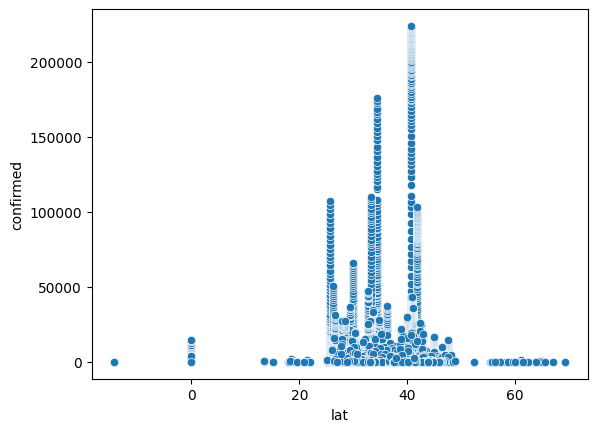

In [31]:
# PREGUNTA 2: ¿Cual es la cantidad de contagiados en relacion a la latitud?
# Gráfico 1: GRÁFICO DE DISPERSIÓN DE CONTAGIOS CONFIRMADOS ASOCIADOS A LA LATITUD.
# Crear una "parcela" de dispersión usando Seaborn:
sns.scatterplot(x="lat", y="confirmed", data=df) #Relacion entre latitud y contagios confirmados 
# Guardar figura:
plt.savefig("scatterplot1.png")
# Mostrar la trama:
plt.show()

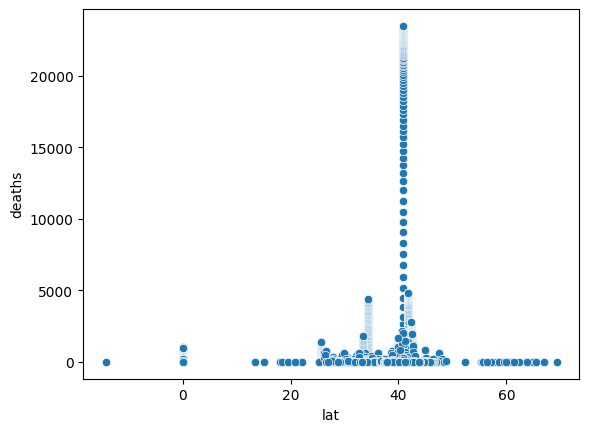

In [32]:
# PREGUNTA 3: ¿Cual es la cantidad de fallecidos en relacion a la latitud?
# Gráfico 2: GRÁFICO DE DISPERSIÓN DE MUERTES ASOCIADAS A LA LATITUD.
# Crear una "parcela" de dispersión usando Seaborn:
sns.scatterplot(x="lat", y="deaths", data=df) #Relacion entre latitud y muertes
# Guardar figura:
plt.savefig("scatterplot2.png")
# Mostrar la trama:
plt.show()

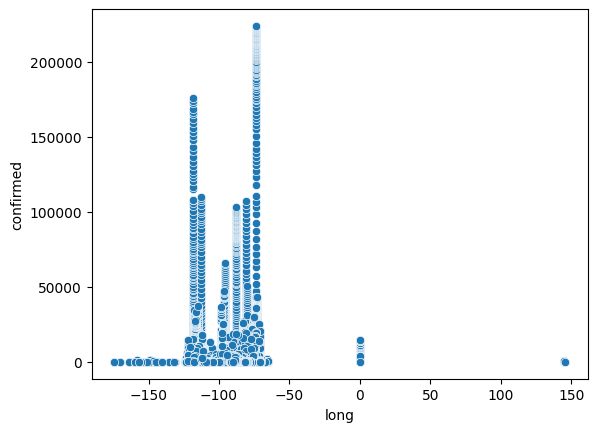

In [33]:
# PREGUNTA 4: ¿Cual es la cantidad de contagiados en relacion a la longitud?
# Gráfico 3: GRÁFICO DE DISPERSIÓN DE CONTAGIOS CONFIRMADOS ASOCIADAS A LA LONGITUD.
# Crear una "parcela" de dispersión usando Seaborn:
sns.scatterplot(x="long", y="confirmed", data=df) #Relacion entre longitud y contagias confirmados
# Guardar figura:
plt.savefig("scatterplot3.png")
# Mostrar la trama:
plt.show()

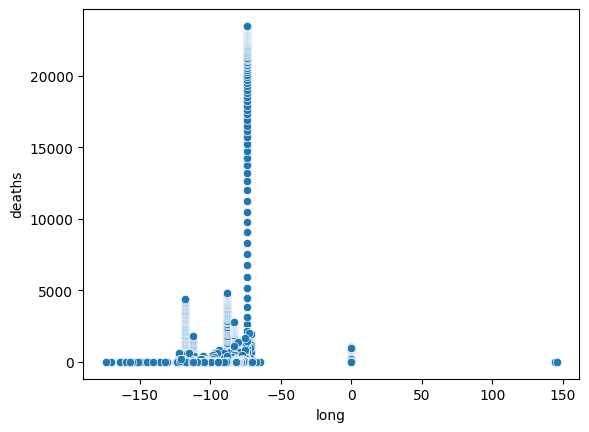

In [34]:
# PREGUNTA 5: ¿Cual es la cantidad de fallecidos en relacion a la longitud?
# Gráfico 4: GRÁFICO DE DISPERSIÓN DE MUERTES ASOCIADAS A LA LONGITUD.
# Crear una "parcela" de dispersión usando Seaborn:
sns.scatterplot(x="long", y="deaths", data=df) #Relacion entre longitud y muertes
# Guardar figura:
plt.savefig("scatterplot4.png")
# Mostrar la trama:
plt.show()

# 3. ¡Vamos con el ML... ¿Qué? ¿Hay que preparar los datos primero?

⁉️ **Consideración:** En las siguientes preguntas harás clusterización y aprendizaje de máquina... prepara tus datos pensando en los modelos que utilizarás. Acá se toman los datos limpios y se pasan a numérico, se cambian las escalas, se agregan columnas para mejorar los resultados de los modelos, etc. Justifica todas tus decisiones.

ℹ️ **HINT:** ¿*Encoding*? ¿Normalización? ¿*Feature Engineering*?

---

✅ **Explicación:**

- **Normalización:** En caso de datos muy dispersos, se ocupa un método que permita tener los datos más comprensibles y analizables.
- **Estandarización:** En caso de tener datos provenientes de fuentes distintas, se busca un método que permita transformar tal dato a un criterio común.

In [35]:
#Eliminar dato irrelevante:
df=df.drop(columns=["yydate"]) #Eliminamos yydate ya que no aporta información relevante.
df.head(3)

,lat,long,mmdate,dddate,confirmed,deaths
0,-14.2710,-170.1320,1,22,0,0
1,13.4443,144.7937,1,22,0,0
2,15.0979,145.6739,1,22,0,0


In [36]:
# Normalización: Para establecer las distiancias, se deben normalizar los datos de modo de permitir su comparacion:
minmax = MinMaxScaler()
df['minmax_lat'] = minmax.fit_transform(df[['lat']])
df['minmax_long'] = minmax.fit_transform(df[['long']])
df['minmax_mmdate'] = minmax.fit_transform(df[['mmdate']])
df['minmax_dddate'] = minmax.fit_transform(df[['dddate']])
df['minmax_confirmed'] = minmax.fit_transform(df[['confirmed']])
df=df.drop(columns=['lat','long','mmdate','dddate','confirmed']) #Se eliminan columnas redundantes por el paso anterior
df=df[['minmax_lat','minmax_long','minmax_mmdate','minmax_dddate','minmax_confirmed','deaths']] #Reordenamos columnas
df.head(5)

,minmax_lat,minmax_long,minmax_mmdate,minmax_dddate,minmax_confirmed,deaths
0,0.000000,0.012593,0.0,0.7,0.0,0
1,0.331579,0.997248,0.0,0.7,0.0,0
2,0.351362,1.000000,0.0,0.7,0.0,0
3,0.388237,0.335816,0.0,0.7,0.0,0
4,0.390392,0.334501,0.0,0.7,0.0,0


In [37]:
# Estandarización: No se aplica, ya que los datos proceden todos de una misma fuente.
df

,minmax_lat,minmax_long,minmax_mmdate,minmax_dddate,minmax_confirmed,deaths
0,0.000000,0.012593,0.0,0.700000,0.000000,0
1,0.331579,0.997248,0.0,0.700000,0.000000,0
2,0.351362,1.000000,0.0,0.700000,0.000000,0
3,0.388237,0.335816,0.0,0.700000,0.000000,0
4,0.390392,0.334501,0.0,0.700000,0.000000,0
...,...,...,...,...,...,...
627915,0.641776,0.195676,1.0,0.866667,0.001549,1
627916,0.637275,0.198410,1.0,0.866667,0.000312,0
627917,0.623616,0.196095,1.0,0.866667,0.012412,23
627918,0.650779,0.202112,1.0,0.866667,0.000634,0


# 4. ¡Grupos everywhere!

⁉️ **Consideración:** Utiliza técnicas de clusterización para encontrar grupos dentro de tus datos. Recuerda colorear tus gráficos correctamente para que podamos ver los grupos. Sí, debes de graficar tus resultados. ¿En 2D, 3D, 4D? Queda a tu decisión. Recuerda que solo puedes usar métodos de clusterización de `sklearn`.

ℹ️ **HINT 1:** No olvides que cada método es diferente. ¿Justificarás por qué elegiste ese método?

ℹ️ **HINT 2:** No olvides explicar cómo eliges tus hiperparámetros.

ℹ️ **HINT 3:** ¿No encuentras grupos? ¿Sabías que PCA y otras técnicas de reducción de dimensionalidad son útiles para *clustering*?

---

✅ **Explicación:**

Se intenta realizar un proceso de aprendizaje de máquina no supervisado, mediante clusterización. Se prueba inicialmente con el algoritmo de K-Means en Google Colab, no obstante, la gran cantidad de datos suministrados (cerca de 630 mil filas de datos) hace que el algoritmo se ejecute durante horas. Se muestra a continuación una clusterización aplicando el método de clustering jerárquico. No obstante, la gran cantidad de datos suministrados impide que el algoritmo se ejecute correctamente: "**Unable to allocate 1.43 TiB for an array with shape (197141449240,) and data type float64**" (No se pueden asignar 1,43 TiB para una matriz con forma (197141449240,) y tipo de datos float64).

In [38]:
df.isna().sum() #Verificamos ausencia de datos nulos:

minmax_lat          0
minmax_long         0
minmax_mmdate       0
minmax_dddate       0
minmax_confirmed    0
deaths              0
dtype: int64

In [39]:
# Dividimos los datos en el conjunto X de entrada, e Y de salida:
x = df[['minmax_lat','minmax_long','minmax_mmdate','minmax_dddate','minmax_confirmed']]
y = df[['deaths']]
x.shape

(627920, 5)

In [40]:
x_scaled = StandardScaler().fit_transform(x) #Se aplicara analisis de componentes principales
x_scaled

array([[-5.62576269, -3.75444553, -1.81298937,  0.68900183, -0.10245357],
       [-2.56720702, 10.74774709, -1.81298937,  0.68900183, -0.10245357],
       [-2.38472198, 10.78827992, -1.81298937,  0.68900183, -0.10245357],
       ...,
       [ 0.12660722, -1.05179066,  1.50151956,  1.25912658,  0.69501611],
       [ 0.37716472, -0.96317126,  1.50151956,  1.25912658, -0.06173416],
       [ 0.50366004, -1.07355531,  1.50151956,  1.25912658,  0.57859299]],
      shape=(627920, 5))

In [41]:
pca = PCA(n_components=3) #Analisis de 3 componentes principales
pca_f = pca.fit_transform(x_scaled)
X = pca_f.copy()
X.shape

(627920, 3)

In [42]:
link = linkage(X, 'ward')
plt.figure(figsize=(10, 10))
dendrogram(link) #Dendograma

MemoryError: Unable to allocate 1.43 TiB for an array with shape (197141449240,) and data type float64

In [43]:
#Clustering Jerárquico:
cluster = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
cluster.fit_predict(X)

TypeError: AgglomerativeClustering.__init__() got an unexpected keyword argument 'affinity'

In [44]:
y_cj = cluster.labels_
print(y_cj)

NameError: name 'cluster' is not defined

NameError: name 'y_cj' is not defined

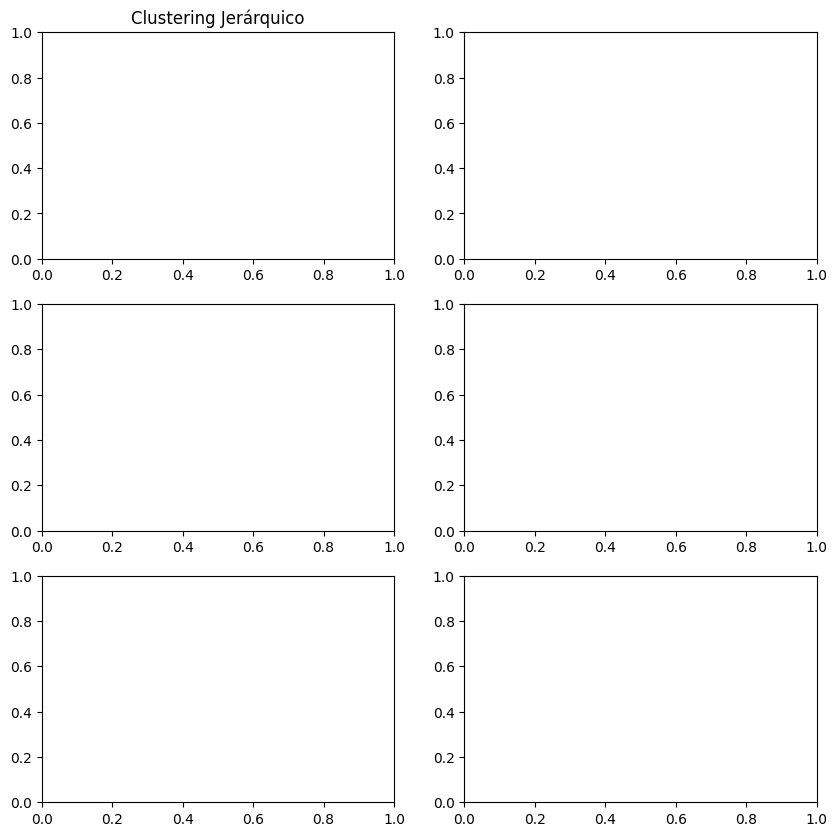

In [45]:
#Visualización Clustering Jerárquico:
fig, ax = plt.subplots(nrows = 3,ncols = 2,figsize = (10,10), dpi=100)
ax[0,0].set_title('Clustering Jerárquico')
l = ax[0,0].scatter(X[:,0], X[:,1], 
           c= y_cj, 
           s=60, 
           alpha=0.3, cmap='rainbow')
ax[1,0].scatter(X[:,0], X[:,2], 
           c= y_cj, 
           s=60, 
           alpha=0.3, cmap='rainbow')
ax[2,0].scatter(X[:,1], X[:,2], 
           c= y_cj, 
           s=60, 
           alpha=0.3, cmap='rainbow')

ax[0,1].set_title('Original')
l2 = ax[0,1].scatter(X[:,0], X[:,1], 
           c= y, 
           s=60, 
           alpha=0.3, cmap='rainbow')
ax[1,1].scatter(X[:,0], X[:,2], 
           c= y, 
           s=60, 
           alpha=0.3, cmap='rainbow')
ax[2,1].scatter(X[:,1], X[:,2], 
           c= y, 
           s=60, 
           alpha=0.3, cmap='rainbow')
legend1 = ax[0,0].legend(*l.legend_elements(),
                    loc="upper left", title="Score")
ax[0,0].add_artist(legend1)

legend2 = ax[0,1].legend(*l2.legend_elements(),
                    loc="upper left", title="Score")
ax[0,1].add_artist(legend2)

In [ ]:
fig = plt.figure(figsize = (8, 8),dpi=100) 
ax = plt.axes(projection ="3d") 
l3d = ax.scatter3D(X[:,0], X[:,1], X[:,2], c=y_cj,alpha=0.5, edgecolor='k',s=50, cmap='rainbow')
ax.set_title('Clustering Jerárquico',fontsize=20)

ax.legend(l3d.legend_elements()[0],[0,1,2,3])

In [46]:
X[:,0]

array([ 1.32213972,  9.4143385 ,  9.31396785, ..., -0.83118559,
       -0.94748175, -1.11346053], shape=(627920,))

In [47]:
X[:,1]

array([-1.784383  , -1.70381215, -1.7025495 , ...,  0.58517861,
        0.29801279,  0.54286616], shape=(627920,))

In [48]:
X[:,2]

array([0.14560404, 0.37381755, 0.37711267, ..., 1.27386696, 0.64699685,
       1.18215386], shape=(627920,))

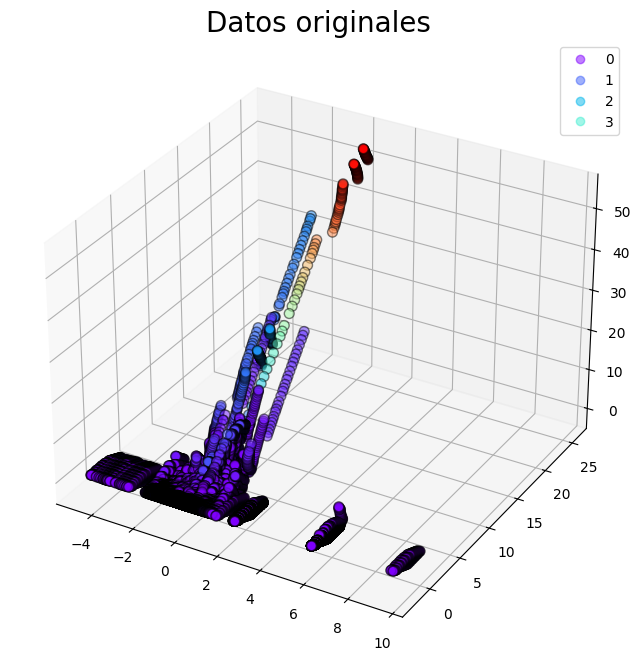

In [49]:
fig = plt.figure(figsize = (8, 8),dpi=100) 
ax = plt.axes(projection ="3d") 
l3d_ = ax.scatter3D(X[:,0], X[:,1], X[:,2], c=y,alpha=0.5, edgecolor='k',s=50, cmap='rainbow')
ax.set_title('Datos originales',fontsize=20)

ax.legend(l3d_.legend_elements()[0],[0,1,2,3])

# 5. ¿Podemos predecir algo con estos datos? Demostremos nuestra experiencia.

⁉️ **Consideración:** Es la hora de aplicar modelos de clasificación o regresión (`sklearn`) a los datos. Enfócate en ser ordenado y seguir todos los pasos: datos, entrenamiento, validación, testeo, interpretación, etc. Debes de explicar a fondo tus decisiones de modelo, parámetros, interpretación de resultados, medidas de rendimiento, etc.

ℹ️ **HINT 1:** ¿Habías escuchado de Validación Cruzada? ¿Has escuchado de `GridSearchCV`?

ℹ️ **HINT 2:** ¿Te fjaste en el *overfitting*?

ℹ️ **HINT 3:** ¿Por qué elegiste ese modelo? Puedes utilizar cualquier modelo de `sklearn`.

ℹ️ **HINT 4:** Se recomienda que comparen varios modelos. ¿Leíste la documentación de `sklearn`?

---

✅ **Explicación:**

Se intenta ejecutar un clasificador RandomForest, sin embargo, al ejecutar el proceso predictor a partir de los datos de validación, la máquina se colapsa. Esto, aparentemente por la gran cantidad de datos suministrados, según lo explicado en la pregunta anterior.

In [50]:
x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

In [51]:
%%time

rf = RandomForestClassifier(
    n_estimators=100,           #Num. arboles, 100 por defecto
    max_depth=3,                #Profundidad del arbol
    max_features=3,             #Num. maximo de caracteristicas a considerar
    #criterion="gini",          #Criterio Gini, por defecto
    random_state=RANDOM_STATE,
    n_jobs=-1                   #Todos los procesadores
)
rf.fit(x_train, y_train)

C:\Users\fmart\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


CPU times: total: 59.2 s
Wall time: 15.7 s


RandomForestClassifier(max_depth=3, max_features=3, n_jobs=-1, random_state=0)

In [52]:
## ¡NO DESCOMENTAR Y EJECUTAR ESTA CELDA! YA QUE COLAPSA LA MAQUINA...
#y_val_pred = rf.predict(x_val)
#
#print('[Random Forest] Check Overfitting with Accuracy')
#print(f'RF: train={accuracy_score(y_train, rf.predict(x_train)):.4f} val={accuracy_score(y_val, y_val_pred):.4f}')

# 6. ¿Puedes explicar mejor tus resultados? ¡De Junior a Senior!

⁉️ **Consideración:** Para pasar de ser una *Data Scientist Junior* a *Senior* deberás ser muy bueno para interpretar y mejorar los resultados de tu modelo. ¿Qué otras mediciones puedes utilizar? ¿Cómo puedes modificar tus datos? ¿Qué datos te faltan? ¿Qué impacta más a tu predicción? ¿Por qué hay métricas más importantes que otras? ¡Y muchas preguntas más! Ahonda en los resultados de tus modelos.

ℹ️ **HINT 1:** ¿Qué otras métricas existen? ¿Matrices de confusión? ¿Por qué hay clases que funcionan peor?

ℹ️ **HINT 2:** ¿Consideraste la reducción de dimensionalidad?

ℹ️ **HINT 3:** ¿Conoces la librería `SHAP`? ¿O los *Partial Dependece Plots*?

---

✅ **Explicación:**

[ AGREGA TU RESPUESTA ACÁ ]

In [ ]:
# [ AGREGA AQUÍ TU CÓDIGO ] ¿Necesitas más celdas? ¡Adelante!

In [ ]:
# [ AGREGA AQUÍ TU CÓDIGO ] ¿Necesitas más celdas? ¡Adelante!

In [ ]:
# [ AGREGA AQUÍ TU CÓDIGO ] ¿Necesitas más celdas? ¡Adelante!

> # ¡NO OLVIDES GUARDAR Y SUBIR EL NOTEBOOK A LA PLATAFORMA CUANDO TERMINES! FORMATO .ipynb

> # ¡NO OLVIDES SUBIR LOS DATOS ORIGINALES A LA PLATAFORMA!